<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/03_Data_Preprocessing_%26_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Image size
2. Number of channels
3. Pixel scaling / model-specific
4. preprocessing
5. Batch size
6. Data augmentation
7. Training/validation/test datasets
8. Verify the resulting images and labels

Step 1 - Load the split dataset and inspect sample images

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Dataset location
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes"

# Selected classes
classes = [
    "kitchen",
    "bedroom",
    "casino",
    "warehouse",
    "inside_subway"
]

# Dataset splits
splits = ["train", "validation", "test"]

print("Dataset exists:", os.path.exists(dataset_dir))

Dataset exists: True


Step 2 — Display one sample from each class

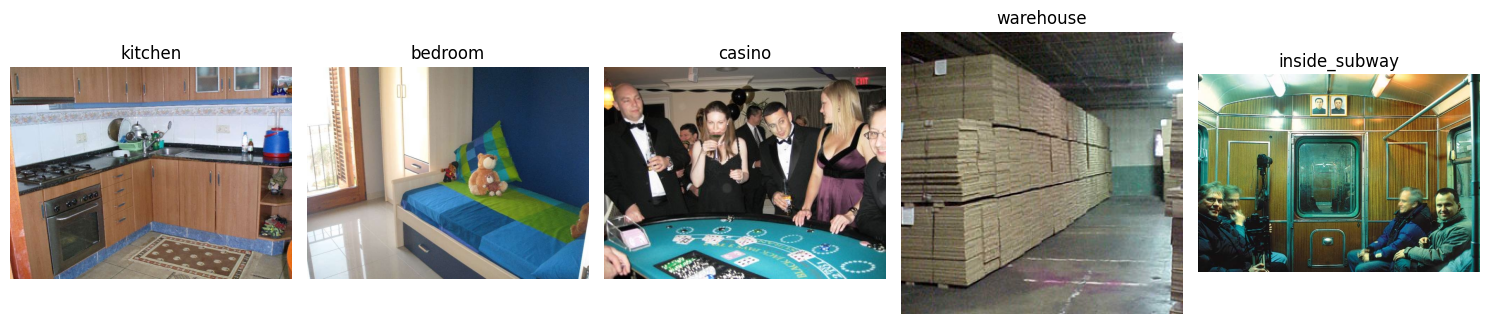

In [ ]:
#kitchen > find training folder > get image filenames > select one image > open image > display image
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_dir, "train", class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, images[0])

    image = Image.open(image_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 3 — Check image sizes and colour mode

In [ ]:
for class_name in classes:

    class_path = os.path.join(dataset_dir, "train", class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, images[0])
    image = Image.open(image_path)

    print(
        f"{class_name:15} | "
        f"Size: {image.size} | "
        f"Mode: {image.mode}"
    )

kitchen         | Size: (798, 598) | Mode: RGB
bedroom         | Size: (798, 598) | Mode: RGB
casino          | Size: (400, 300) | Mode: RGB
warehouse       | Size: (256, 256) | Mode: RGB
inside_subway   | Size: (700, 490) | Mode: RGB


Step 4 — Load the train, validation and test datasets

In [ ]:
#set image size and batch size
image_size = (224, 224) #224 × 224 gives every image the same input size, which is required when images are grouped into batches
batch_size = 32 #Batch size = 32 means the model processes 32 images at a time during training

In [ ]:
#Load the three datasets
train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred", #Labels are taken from the folder names
    label_mode="int", #Classes are represented using integer labels
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2009 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.


In [ ]:
#Check the dataset output
print("Class names:", train_ds.class_names)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Class names: ['kitchen', 'bedroom', 'casino', 'warehouse', 'inside_subway']
Training batches: 63
Validation batches: 14
Test batches: 14


Step 5 — Verify image and label shapes

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Label data type:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


Step 6 — Check the label values

In [ ]:
for images, labels in train_ds.take(1):
    print("Labels:", labels.numpy())

Labels: [2 0 1 3 4 1 2 4 2 0 2 3 0 1 1 3 3 0 1 4 0 4 2 0 0 4 2 3 2 0 2 0]


Step 7 — Verify the resulting resized images

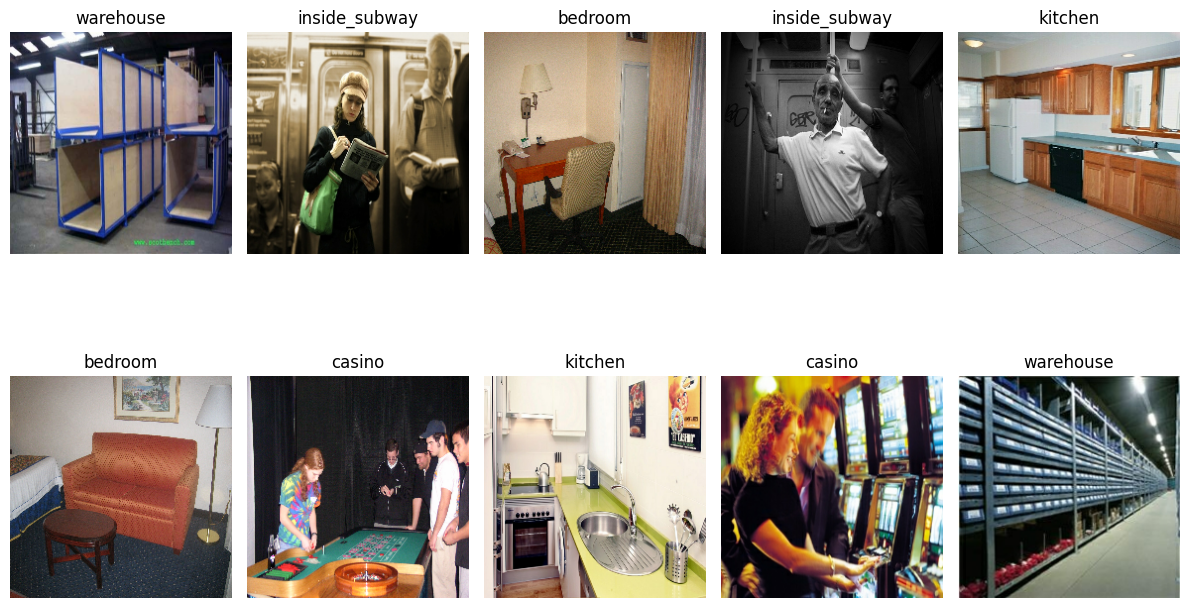

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(10):

        plt.subplot(2, 5, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(classes[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()

Step 8 — Pixel Scaling / Model-Specific Preprocessing

In [ ]:
#check the current pixel range
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


Step 9 — Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #The same room can be viewed from different directions
    tf.keras.layers.RandomRotation(0.5), #Camera may not always be perfectly level
    tf.keras.layers.RandomZoom(0.1), #Camera can be positioned at different distances
    tf.keras.layers.RandomContrast(0.1) #Indoor lighting conditions can vary
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


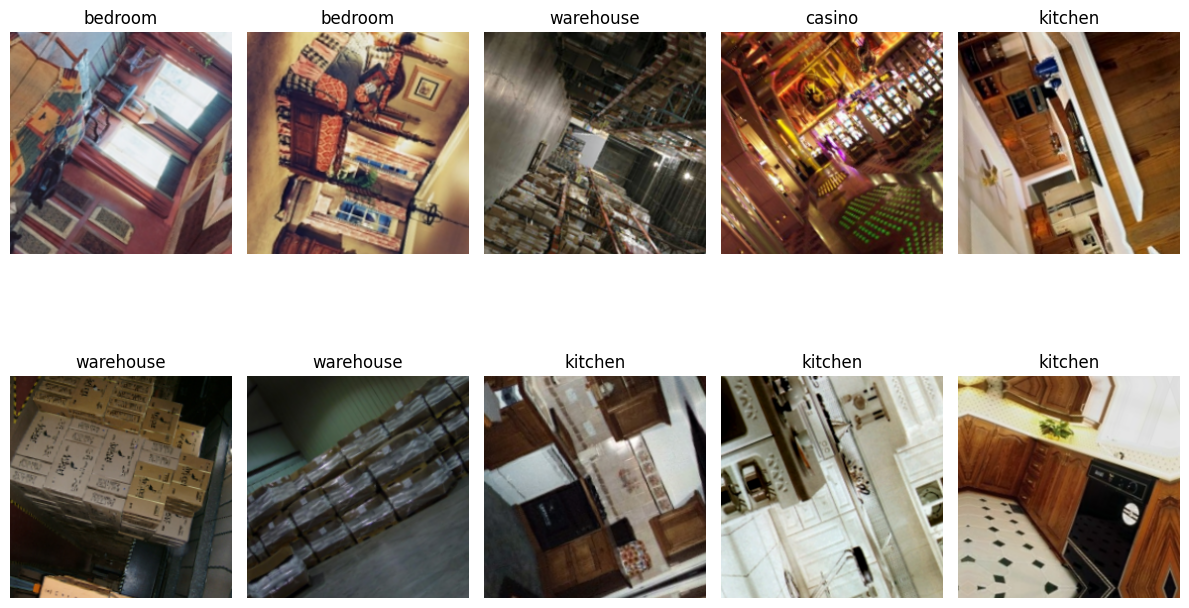

In [ ]:
#Visualize the Augmentation
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(classes[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

Step 10 — Optimize the Dataset Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset prefetching configured.")

Dataset prefetching configured.
